<div align="center">

<h1> <b> RADIO NUCLEAR A PARTIR DE LAS ENERGÍAS DE DESPLAZAMIENTO DE COULOMB EN NÚCLEOS ESPEJO </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Giovanni Stiven Rojas Benjumea <br>
Cristian Camilo Vergara Restrepo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción

Los núcleos espejo son pares de núcleos con el mismo número másico $A$ en los que el número de protones de uno coincide con el número de neutrones del otro: $(Z,N)$ y $(N,Z)$. Bajo la hipótesis de simetría de carga de la fuerza nuclear, la interacción nuclear fuerte es idéntica para ambos miembros del par, de modo que la diferencia de energía de enlace entre ellos se debe, en muy buena aproximación, únicamente a la diferencia de energía electrostática asociada al protón adicional.

Este notebook analiza el archivo `delta_coulomb.dat`, que contiene, para una serie de pares de núcleos espejo con $A$ impar entre 3 y 59, dos columnas:

- **Columna 1:** el número másico $A$.
- **Columna 2:** la energía de desplazamiento coulombiano $\Delta E_C$, en keV.

**Modelo.** Si el núcleo se representa como una esfera uniformemente cargada de radio $R = r_0 A^{1/3}$, su energía coulombiana es

$$
E_C(Z) = \frac{3}{5}\,\frac{e^2}{4\pi\epsilon_0\,R}\,Z(Z-1).
$$

Para $A$ impar, un par espejo tiene exactamente $Z_> = (A+1)/2$ protones en el miembro más rico en protones y $Z_< = (A-1)/2$ en el otro, de modo que $Z_> - Z_< = 1$ y $Z_> + Z_< = A$. La energía de desplazamiento coulombiano es entonces

$$
\Delta E_C = E_C(Z_>) - E_C(Z_<)
= \frac{3}{5}\,\frac{e^2}{4\pi\epsilon_0\,R}\big[Z_>(Z_>-1) - Z_<(Z_<-1)\big]
= \frac{3}{5}\,\frac{e^2}{4\pi\epsilon_0\,r_0}\left(A^{2/3} - A^{-1/3}\right),
$$

donde se usó $R = r_0 A^{1/3}$. En el rango de $A$ considerado, el término $A^{-1/3}$ es pequeño y varía lentamente frente a $A^{2/3}$; junto con correcciones adicionales que el modelo de esfera uniforme no incluye (difusividad de la superficie nuclear, energía de intercambio coulombiano), su efecto puede absorberse aproximadamente en una constante, de modo que los datos se describen bien mediante la relación lineal

$$
\Delta E_C \,(\text{MeV}) = m\,A^{2/3} + b, \qquad
m = \frac{3}{5}\,\frac{e^2}{4\pi\epsilon_0\,r_0}.
$$

De la pendiente $m$ se obtiene el radio nuclear:

$$
r_0 = \frac{3}{5}\,\frac{e^2}{4\pi\epsilon_0\,m}.
$$

$m$ y $r_0$ son positivos, pues $\Delta E_C$ crece con $A$: agregar un protón adicional siempre incrementa la energía coulombiana del núcleo. Para la constante $e^2/(4\pi\epsilon_0)$ se usa el valor estándar en unidades nucleares, $e^2/(4\pi\epsilon_0) \approx 1.44$ MeV·fm (Krane, 1988).

El procedimiento consiste en:

1. Convertir $\Delta E_C$ de keV a MeV y calcular $A^{2/3}$.
2. Ajustar por mínimos cuadrados la relación lineal $\Delta E_C = m\,A^{2/3} + b$.
3. Obtener $r_0$, con su incertidumbre, a partir de la pendiente $m$.
4. Graficar $\Delta E_C$ frente a $A^{2/3}$ junto con el ajuste, y los residuos del ajuste frente a $A^{2/3}$, para evaluar la calidad del modelo lineal.

## 2. Carga y preparación de los datos

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Archivo de datos: numero masico A y energia de desplazamiento
# coulombiano Delta_E_C (en keV) para cada par de nucleos espejo.
RUTA_DATOS = "delta_coulomb.dat"

datos = np.loadtxt(RUTA_DATOS)
A = datos[:, 0]
delta_Ec_keV = datos[:, 1]

# El modelo de la Seccion 1 esta expresado en MeV; se convierte una
# sola vez para no repetir la conversion en cada calculo posterior.
delta_Ec = delta_Ec_keV / 1000.0

# Variable independiente del ajuste lineal (ver Seccion 1).
x = A**(2 / 3)

print(f"Numero de pares de nucleos espejo: {len(A)}")
print(f"Rango de A: {A.min():.0f} - {A.max():.0f}")
print(f"Rango de Delta_E_C: {delta_Ec.min():.3f} - {delta_Ec.max():.3f} MeV")

Numero de pares de nucleos espejo: 27
Rango de A: 3 - 59
Rango de Delta_E_C: 0.764 - 9.874 MeV


## 3. Ajuste lineal por mínimos cuadrados

Se ajusta el modelo $\Delta E_C = m\,A^{2/3} + b$ a los datos experimentales mediante mínimos cuadrados no lineales (`scipy.optimize.curve_fit`), y se obtiene el radio nuclear $r_0$, con su incertidumbre asociada, a partir de la pendiente del ajuste.

In [3]:
def modelo_lineal(x, m, b):
    """
    Modelo lineal Delta_E_C = m*x + b, con x = A^(2/3) (ver Seccion 1).

    Parameters
    ----------
    x : array_like
        Valores de A^(2/3) (adimensional).
    m : float
        Pendiente del ajuste, en MeV.
    b : float
        Intercepto del ajuste, en MeV.

    Returns
    -------
    array_like
        Delta_E_C predicho por el modelo, en MeV.
    """
    return m * x + b


# Ajuste por minimos cuadrados de m y b. No se cuenta con incertidumbres
# experimentales por punto, de modo que curve_fit asume errores iguales
# y escala la covarianza con la varianza residual (absolute_sigma=False,
# el comportamiento por defecto).
popt, pcov = curve_fit(modelo_lineal, x, delta_Ec)
m, b = popt
error_m, error_b = np.sqrt(np.diag(pcov))

# Constante e^2/(4*pi*eps0) en unidades nucleares (MeV*fm; Krane, 1988).
e2_4pieps0 = 1.44  # MeV*fm

# Radio nuclear a partir de la pendiente del ajuste (ver Seccion 1),
# con su incertidumbre propagada linealmente desde la de m.
r0_fm = (3 * e2_4pieps0) / (5 * m)
error_r0_fm = r0_fm * (error_m / m)

# Bondad del ajuste (coeficiente de determinacion R^2).
prediccion = modelo_lineal(x, *popt)
ss_res = np.sum((delta_Ec - prediccion)**2)
ss_tot = np.sum((delta_Ec - delta_Ec.mean())**2)
r_cuadrado = 1 - ss_res / ss_tot

print(f"m = {m:.4f} +/- {error_m:.4f} MeV")
print(f"b = {b:.4f} +/- {error_b:.4f} MeV")
print(f"R^2 = {r_cuadrado:.4f}")
print(f"r0 = {r0_fm:.3f} +/- {error_r0_fm:.3f} fm")

m = 0.7076 +/- 0.0070 MeV
b = -0.9291 +/- 0.0687 MeV
R^2 = 0.9976
r0 = 1.221 +/- 0.012 fm


## 4. Gráfica de $\Delta E_C$ frente a $A^{2/3}$

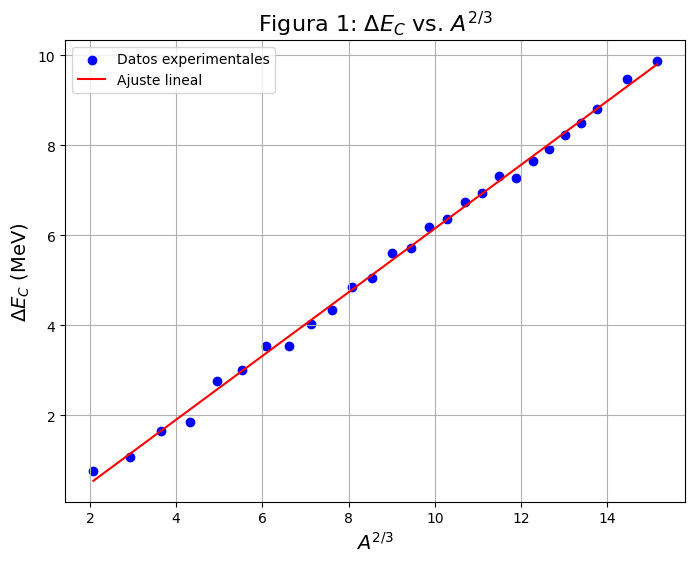

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(x, delta_Ec, color="blue", label="Datos experimentales")
plt.plot(x, modelo_lineal(x, *popt), color="red", label="Ajuste lineal")
plt.xlabel(r"$A^{2/3}$", fontsize=14)
plt.ylabel(r"$\Delta E_C$ (MeV)", fontsize=14)
plt.title(r"Figura 1: $\Delta E_C$ vs. $A^{2/3}$", fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

**Figura 1**: los puntos azules son los valores experimentales de $\Delta E_C$ para cada par de núcleos espejo, y la línea roja es el ajuste lineal obtenido por mínimos cuadrados. La tendencia lineal entre $\Delta E_C$ y $A^{2/3}$, con un coeficiente de determinación cercano a 1, respalda el modelo de esfera uniformemente cargada para la energía coulombiana nuclear.

## 5. Análisis de residuos

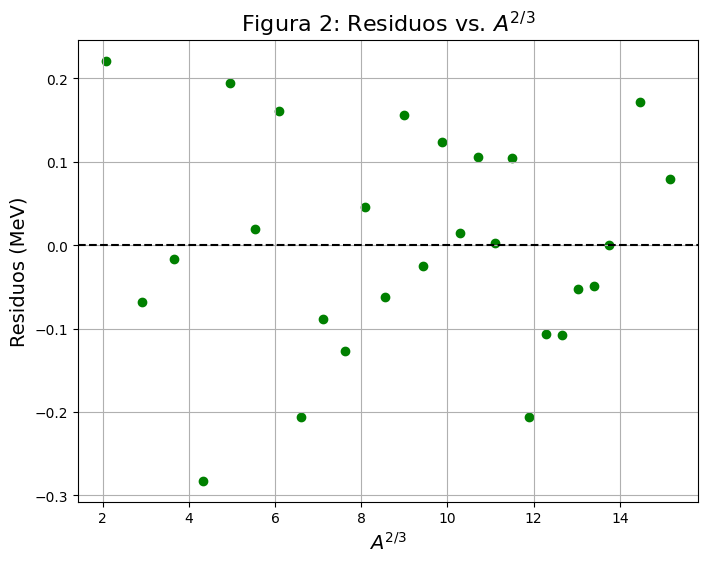

In [5]:
# Residuos del ajuste lineal.
residuos = delta_Ec - modelo_lineal(x, *popt)

plt.figure(figsize=(8, 6))
plt.scatter(x, residuos, color="green")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel(r"$A^{2/3}$", fontsize=14)
plt.ylabel("Residuos (MeV)", fontsize=14)
plt.title(r"Figura 2: Residuos vs. $A^{2/3}$", fontsize=16)
plt.grid(True)
plt.show()

**Figura 2**: los residuos $\Delta E_C - (\text{ajuste})$ se distribuyen de manera relativamente uniforme alrededor de cero, sin una tendencia sistemática ni curvatura marcada, lo que indica que el modelo lineal describe adecuadamente la dependencia de $\Delta E_C$ con $A^{2/3}$ en el rango de datos disponible.

---

## 6. Conclusiones

1. **Validez del modelo lineal.** La ausencia de un patrón sistemático en los residuos, junto con un coeficiente de determinación $R^2 \approx 0.998$, indica que la relación $\Delta E_C \propto A^{2/3}$ describe razonablemente bien los datos experimentales de energía de desplazamiento coulombiano para los núcleos espejo considerados.

2. **Radio nuclear.** El valor de $r_0$ obtenido a partir de la pendiente del ajuste es $r_0 = 1.221 \pm 0.012$ fm, consistente con el rango típico reportado en la literatura para el radio nuclear por nucleón ($r_0 \approx 1.2\text{-}1.25$ fm).

3. **Consistencia física.** El acuerdo entre el valor de $r_0$ obtenido y los valores esperados respalda tanto la hipótesis de simetría de carga de la fuerza nuclear como el modelo de esfera uniformemente cargada para la energía coulombiana.

---

## Referencias

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., … Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, *585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

Krane, K. S. (1988). *Introductory nuclear physics*. John Wiley & Sons.

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., … van Mulbregt, P. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, *17*(3), 261–272. https://doi.org/10.1038/s41592-019-0686-2

*Nota:* los valores de $\Delta E_C$ empleados corresponden a un conjunto de pares de núcleos espejo con $A$ impar (3 ≤ A ≤ 59), en el formato típico de las tablas de energías de desplazamiento coulombiano de la física nuclear (Krane, 1988); no fue posible confirmar con certeza la tabla o edición exacta de la que proviene el archivo de datos.